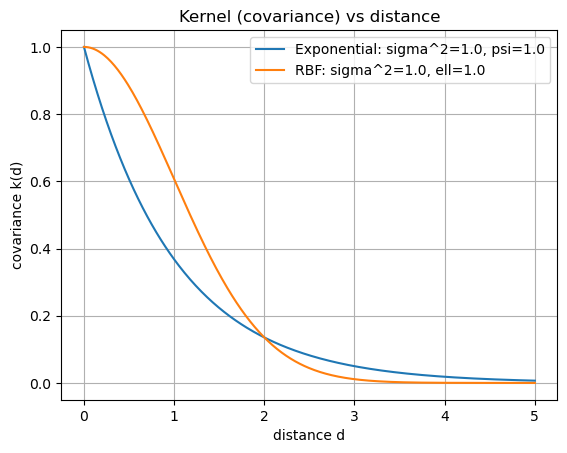

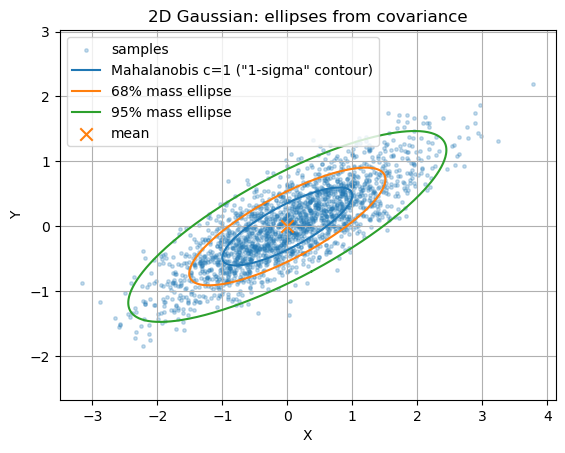

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Kernel / covariance vs distance
# -----------------------------
def exp_kernel(d, sigma2=1.0, psi=1.0):
    # k(d) = sigma^2 * exp(-psi * d)
    return sigma2 * np.exp(-psi * d)

def rbf_kernel(d, sigma2=1.0, ell=1.0):
    # k(d) = sigma^2 * exp(-(d^2)/(2*ell^2))
    return sigma2 * np.exp(-(d**2) / (2 * ell**2))

d = np.linspace(0, 5, 400)

sigma2 = 1.0
psi = 1.0      # for exponential
ell = 1.0      # for RBF

k_exp = exp_kernel(d, sigma2=sigma2, psi=psi)
k_rbf = rbf_kernel(d, sigma2=sigma2, ell=ell)

plt.figure()
plt.plot(d, k_exp, label=f"Exponential: sigma^2={sigma2}, psi={psi}")
plt.plot(d, k_rbf, label=f"RBF: sigma^2={sigma2}, ell={ell}")
plt.xlabel("distance d")
plt.ylabel("covariance k(d)")
plt.title("Kernel (covariance) vs distance")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2) Joint Gaussian ellipse plot
# -----------------------------
def chi2_c_for_mass_2d(p):
    """
    For 2D Gaussian, (x-mu)^T Sigma^{-1} (x-mu) ~ ChiSquare(df=2).
    CDF for df=2 is: F(c) = 1 - exp(-c/2).
    So c = -2 * ln(1-p).
    """
    return -2.0 * np.log(1.0 - p)

def ellipse_points(mu, Sigma, c=1.0, n=400):
    """
    Returns points on ellipse: (z-mu)^T Sigma^{-1} (z-mu) = c
    Semi-axis lengths are sqrt(c*eigenvalues), directions are eigenvectors.
    """
    vals, vecs = np.linalg.eigh(Sigma)  # eigenvalues ascending
    vals = np.maximum(vals, 0)          # safety for tiny negatives from numerics

    t = np.linspace(0, 2*np.pi, n)
    circle = np.stack([np.cos(t), np.sin(t)], axis=0)  # (2, n)

    # scale circle to ellipse in eigenbasis, then rotate back
    scale = np.diag(np.sqrt(c * vals))
    ell = (vecs @ scale @ circle).T + mu  # (n, 2)
    return ell

# Choose a mean and covariance (edit these)
mu = np.array([0.0, 0.0])
sx, sy = 1.0, 0.6
rho = 0.8  # correlation in [-1, 1]
Sigma = np.array([[sx**2, rho*sx*sy],
                  [rho*sx*sy, sy**2]])

# Ellipse levels:
# "1-sigma" Mahalanobis contour uses c=1 (not 68% mass in 2D).
c_1sigma = 1.0
# Ellipses that contain 68% and 95% probability mass in 2D:
c_68 = chi2_c_for_mass_2d(0.68)
c_95 = chi2_c_for_mass_2d(0.95)

E1 = ellipse_points(mu, Sigma, c=c_1sigma)
E68 = ellipse_points(mu, Sigma, c=c_68)
E95 = ellipse_points(mu, Sigma, c=c_95)

# Sample points from the Gaussian to visually sanity-check
rng = np.random.default_rng(0)
samples = rng.multivariate_normal(mean=mu, cov=Sigma, size=2000)

plt.figure()
plt.scatter(samples[:,0], samples[:,1], s=6, alpha=0.25, label="samples")
plt.plot(E1[:,0], E1[:,1], label="Mahalanobis c=1 (\"1-sigma\" contour)")
plt.plot(E68[:,0], E68[:,1], label="68% mass ellipse")
plt.plot(E95[:,0], E95[:,1], label="95% mass ellipse")
plt.scatter([mu[0]], [mu[1]], marker="x", s=80, label="mean")
plt.axis("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Gaussian: ellipses from covariance")
plt.legend()
plt.grid(True)
plt.show()


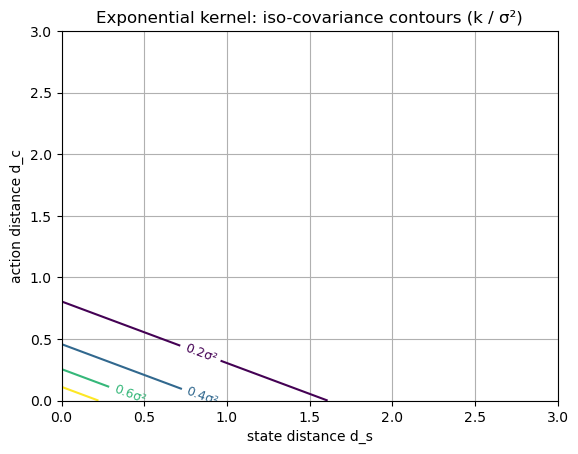

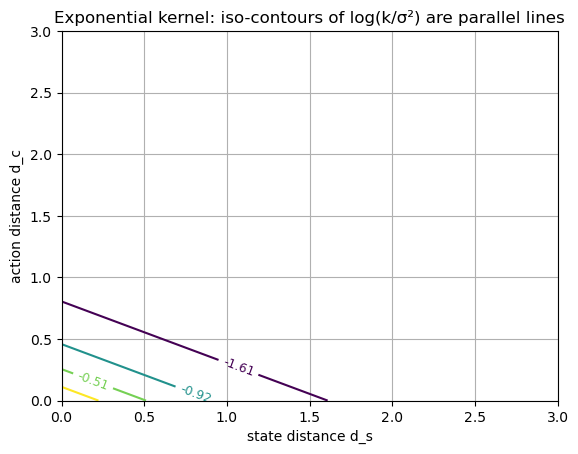

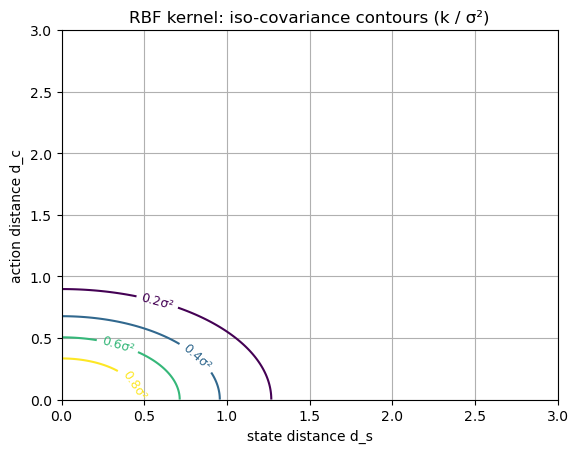

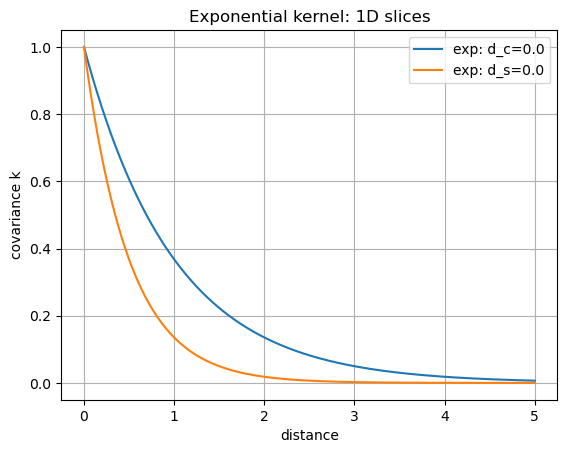

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Kernel definitions
# -----------------------------
def exp_kernel(ds, dc, sigma2=1.0, psi_s=1.0, psi_c=1.0):
    return sigma2 * np.exp(-psi_s * ds - psi_c * dc)

def rbf_kernel(ds, dc, sigma2=1.0, psi_s=1.0, psi_c=1.0):
    return sigma2 * np.exp(-psi_s * ds**2 - psi_c * dc**2)

# -----------------------------
# Parameters (edit these)
# -----------------------------
sigma2 = 1.0
psi_s = 1.0
psi_c = 2.0

# Grid over distances
ds = np.linspace(0, 3, 301)
dc = np.linspace(0, 3, 301)
DS, DC = np.meshgrid(ds, dc)

K_exp = exp_kernel(DS, DC, sigma2=sigma2, psi_s=psi_s, psi_c=psi_c)
K_rbf = rbf_kernel(DS, DC, sigma2=sigma2, psi_s=psi_s, psi_c=psi_c)

# Choose iso-covariance levels as fractions of sigma^2 (must be increasing for contour)
levels_frac = np.array([0.2, 0.4, 0.6, 0.8])
levels_exp = sigma2 * levels_frac
levels_rbf = sigma2 * levels_frac

# -----------------------------
# Plot: Exponential kernel iso-covariance contours
# -----------------------------
plt.figure()
cs = plt.contour(DS, DC, K_exp, levels=levels_exp)
plt.clabel(cs, inline=True, fontsize=9, fmt=lambda v: f"{v/sigma2:.1f}σ²")
plt.xlabel("state distance d_s")
plt.ylabel("action distance d_c")
plt.title("Exponential kernel: iso-covariance contours (k / σ²)")
plt.grid(True)
plt.show()

# Optional: log-k contours (shows linearity in distances)
plt.figure()
logK_exp = np.log(np.maximum(K_exp / sigma2, 1e-12))
cs2 = plt.contour(DS, DC, logK_exp, levels=np.log(levels_frac))
plt.clabel(cs2, inline=True, fontsize=9, fmt=lambda v: f"{v:.2f}")
plt.xlabel("state distance d_s")
plt.ylabel("action distance d_c")
plt.title("Exponential kernel: iso-contours of log(k/σ²) are parallel lines")
plt.grid(True)
plt.show()

# -----------------------------
# Plot: RBF kernel iso-covariance contours
# -----------------------------
plt.figure()
cs3 = plt.contour(DS, DC, K_rbf, levels=levels_rbf)
plt.clabel(cs3, inline=True, fontsize=9, fmt=lambda v: f"{v/sigma2:.1f}σ²")
plt.xlabel("state distance d_s")
plt.ylabel("action distance d_c")
plt.title("RBF kernel: iso-covariance contours (k / σ²)")
plt.grid(True)
plt.show()

# -----------------------------
# Bonus: 1D slices (hold one distance fixed)
# -----------------------------
d = np.linspace(0, 5, 400)
dc_fixed = 0.0
ds_fixed = 0.0

k_exp_ds = exp_kernel(d, dc_fixed, sigma2=sigma2, psi_s=psi_s, psi_c=psi_c)
k_exp_dc = exp_kernel(ds_fixed, d, sigma2=sigma2, psi_s=psi_s, psi_c=psi_c)

plt.figure()
plt.plot(d, k_exp_ds, label=f"exp: d_c={dc_fixed}")
plt.plot(d, k_exp_dc, label=f"exp: d_s={ds_fixed}")
plt.xlabel("distance")
plt.ylabel("covariance k")
plt.title("Exponential kernel: 1D slices")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
import numpy as np
import plotly.graph_objects as go

# ----------------------------
# "Internal" parameters (used for geometry only; no numeric labels shown)
# ----------------------------
sigma2 = 1.0        # corresponds to σ_0^2 (we will label it symbolically)
psi_s  = 1.0        # exponential rate
ell    = 1.25       # RBF lengthscale

# Distance axis
dmax = 6.0
d = np.linspace(0, dmax, 800)

# Kernels (1D slice, i.e., action fixed)
k_exp = sigma2 * np.exp(-psi_s * d)                 # σ_0^2 exp(-ψ_s d)
k_rbf = sigma2 * np.exp(-(d**2) / (ell**2))         # σ_0^2 exp(-d^2/ℓ^2)

# Landmark x-locations (numeric for plotting; symbolic for tick labels)
x_1overpsi = 1.0 / psi_s
x_2overpsi = 2.0 / psi_s

# Intersection (nonzero solution): exp(-ψ d) = exp(-d^2/ℓ^2) => d* = ψ ℓ^2
x_star = psi_s * (ell**2)
y_star = sigma2 * np.exp(-psi_s * x_star)

# Landmark y-levels
y0   = sigma2
y1e  = sigma2 / np.e
y1e2 = sigma2 / (np.e**2)

fig = go.Figure()

# Curves
fig.add_trace(go.Scatter(
    x=d, y=k_exp, mode="lines",
    name=r"$k_{\mathrm{exp}}(d)=\sigma_0^2\exp(-\psi_s d)$"
))
fig.add_trace(go.Scatter(
    x=d, y=k_rbf, mode="lines",
    name=r"$k_{\mathrm{RBF}}(d)=\sigma_0^2\exp(-d^2/\ell^2)$"
))

# Intersection point
fig.add_trace(go.Scatter(
    x=[x_star], y=[y_star], mode="markers",
    marker=dict(size=7, symbol="circle", color="red"),
    name=r"$d^\star:\ k_{\mathrm{exp}}(d^\star)=k_{\mathrm{RBF}}(d^\star)$"
))

# Horizontal reference lines (σ0^2, σ0^2/e, σ0^2/e^2)
for yref, dash in [(y0, "solid"), (y1e, "dash"), (y1e2, "dash")]:
    fig.add_shape(
        type="line", x0=0, x1=dmax, y0=yref, y1=yref,
        line=dict(width=1, dash=dash)
    )

# Vertical line at 1/ψ_s (where exp-kernel hits σ0^2/e)
fig.add_shape(
    type="line", x0=x_1overpsi, x1=x_1overpsi, y0=0, y1=y1e,
    line=dict(width=1, dash="dash")
)

# A simple "interval" marker under x-axis (0 to 1/ψ_s) + label (brace-like)
# (Plotly doesn't have a native brace; this is a clean substitute.)
y_under = -0.08 * sigma2
fig.add_shape(
    type="line", x0=0, x1=x_1overpsi, y0=y_under, y1=y_under,
    line=dict(width=1)
)
fig.add_shape(
    type="line", x0=0, x1=0, y0=y_under-0.02*sigma2, y1=y_under+0.02*sigma2,
    line=dict(width=1)
)
fig.add_shape(
    type="line", x0=x_1overpsi, x1=x_1overpsi, y0=y_under-0.02*sigma2, y1=y_under+0.02*sigma2,
    line=dict(width=1)
)
fig.add_annotation(
    x=0.5*x_1overpsi, y=y_under-0.04*sigma2, showarrow=False,
    text=r"$k_{\mathrm{exp}}:\ \sigma_0^2 \rightarrow \sigma_0^2/e$",
    font=dict(size=10)
)

# Axes: remove numeric ticks, but keep symbolic ticks at key points/levels
fig.update_xaxes(
    title_text=r"$\|\Delta s\|$",
    range=[0, dmax],
    tickmode="array",
    tickvals=[x_1overpsi, x_2overpsi, x_star],
    ticktext=[r"$1/\psi_s$", r"$2/\psi_s$", r"$d^\star$"],
    showgrid=False,
    zeroline=False
)
fig.update_yaxes(
    title_text=r"$k(\cdot)$",
    range=[-0.14*sigma2, 1.10*sigma2],
    tickmode="array",
    tickvals=[y0, y1e, y1e2],
    ticktext=[r"$\sigma_0^2$", r"$\sigma_0^2/e$", r"$\sigma_0^2/e^2$"],
    showgrid=False,
    zeroline=False
)

# Layout: white background, compact, small-ish typography feel
fig.update_layout(
    width=700, height=420,
    margin=dict(l=60, r=20, t=30, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(
        x=0.02, y=0.98, xanchor="left", yanchor="top",
        bgcolor="rgba(255,255,255,0.7)"
    ),
    font=dict(size=10)
)

fig.show()


In [9]:
import plotly.graph_objs as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[1, 4, 9, 16],
    name=r'$\alpha_{1c} = 352 \pm 11 \text{ km s}^{-1}$'
))
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[0.5, 2, 4.5, 8],
    name=r'$\beta_{1c} = 25 \pm 11 \text{ km s}^{-1}$'
))
fig.update_layout(
    xaxis_title=r'$\sqrt{(n_\text{c}(t|{T_\text{early}}))}$',
    yaxis_title=r'$d, r \text{ (solar radius)}$'
)
fig.show()

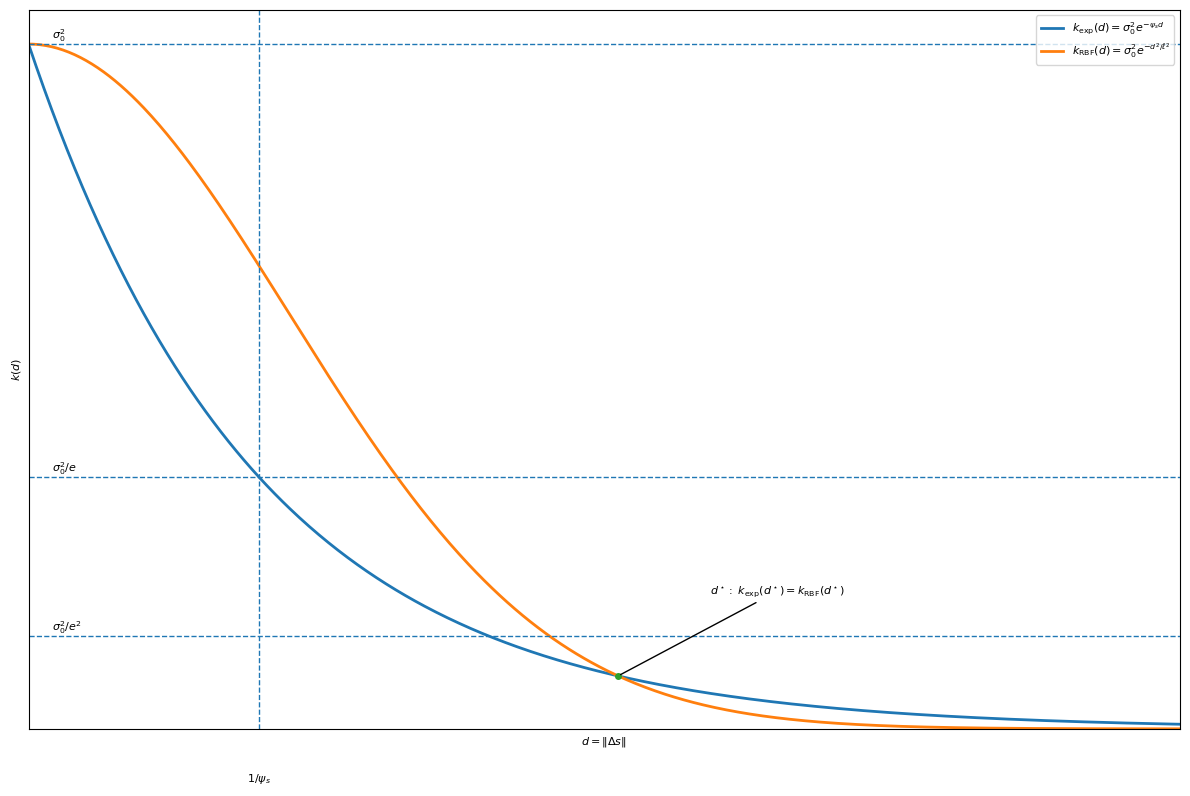

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters (choose these; plot labels are symbolic) ---
sigma2 = 1.0      # σ0^2 (scale only)
psi_s  = 1.0      # exponential rate
ell    = 1.6      # RBF lengthscale

# --- Kernels as functions of distance d = ||Δs|| ---
def k_exp(d):
    return sigma2 * np.exp(-psi_s * d)

def k_rbf(d):
    return sigma2 * np.exp(-(d**2) / (ell**2))

# Domain
d = np.linspace(0, 5, 600)

# Curves
y_exp = k_exp(d)
y_rbf = k_rbf(d)

# Landmark levels (symbolic labels; numeric values only for placement)
y0  = sigma2
y1e = sigma2 / np.e
y1e2 = sigma2 / (np.e**2)

# Exponential "1/e" distance: k_exp(d)=σ0^2/e => d = 1/ψs
d_1e = 1.0 / psi_s
# Intersection: exp(-ψ d) = exp(-d^2/ℓ^2) => d* = ψ ℓ^2
d_star = psi_s * (ell**2)
y_star = k_exp(d_star)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(d, y_exp, linewidth=2.0, label=r"$k_{\mathrm{exp}}(d)=\sigma_0^2 e^{-\psi_s d}$")
ax.plot(d, y_rbf, linewidth=2.0, label=r"$k_{\mathrm{RBF}}(d)=\sigma_0^2 e^{-d^2/\ell^2}$")

# Horizontal reference lines (σ0^2, σ0^2/e, σ0^2/e^2)
for y, lab in [(y0, r"$\sigma_0^2$"),
               (y1e, r"$\sigma_0^2/e$"),
               (y1e2, r"$\sigma_0^2/e^2$")]:
    ax.axhline(y, linestyle="--", linewidth=1.0)
    ax.text(0.02, y, lab, va="bottom", ha="left", fontsize=8,
            transform=ax.get_yaxis_transform())

# Vertical guide at 1/ψs (where exp hits 1/e)
ax.axvline(d_1e, linestyle="--", linewidth=1.0)
ax.text(d_1e, -0.06, r"$1/\psi_s$", ha="center", va="top", fontsize=8,
        transform=ax.get_xaxis_transform())

# Intersection point (annotated)
ax.plot([d_star], [y_star], marker="o", markersize=4)
ax.annotate(r"$d^\star:\ k_{\mathrm{exp}}(d^\star)=k_{\mathrm{RBF}}(d^\star)$",
            xy=(d_star, y_star),
            xytext=(d_star+0.4, y_star+0.12),
            fontsize=8,
            arrowprops=dict(arrowstyle="-", linewidth=1.0))

# Axes labels (symbolic)
ax.set_xlabel(r"$d=\|\Delta s\|$", fontsize=8)
ax.set_ylabel(r"$k(d)$", fontsize=8)

# Remove numeric tick labels (keep clean, “no numbers shown”)
ax.set_xticks([])
ax.set_yticks([])

# Limits and styling
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.05 * sigma2)
ax.legend(fontsize=8, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

class FittedAgent:
    def __init__(self):
        # We use a Radial Basis Function (RBF) kernel
        # This captures the "decreasing in distance" property from the text (Section 2.4.4)
        # WhiteKernel handles the "noise" in the reasoning/experience signals
        kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
        
        # The 'optimizer' param will automatically tune the "reasoning precision"
        self.model = GaussianProcessRegressor(kernel=kernel, optimizer=None)
        
        # History of observations (Experience)
        self.X_history = np.empty((0, 2)) # Inputs: [Wealth, Consumption]
        self.y_history = np.empty((0,))   # Targets: [Utility]
        
        # Initial belief (Prior Mean)
        # We add some "dummy" initial data to represent the prior bias
        self.add_prior_bias("saver") # or "spender"

    def add_prior_bias(self, bias_type):
        """Adds fake initial data to shape the agent's starting beliefs"""
        # Create a few heuristic points to 'seed' the Gaussian Process
        s_seed = np.linspace(1, 5, 5)
        c_seed = np.linspace(0.5, 3, 5)
        X_seed = np.column_stack((s_seed, c_seed))
        
        if bias_type == "saver":
            # Biased to think Saving (low c) gives High Utility
            y_seed = np.log(c_seed) + 0.5 * (s_seed - c_seed)
        else:
             # Biased to think Spending (high c) gives High Utility
            y_seed = np.log(c_seed) + 0.1 * (s_seed - c_seed)

        self.X_history = np.vstack((self.X_history, X_seed))
        self.y_history = np.hstack((self.y_history, y_seed))
        
        # Fit the model immediately to establish the "Prior" for t=0
        self.model.fit(self.X_history, self.y_history)

    def get_belief(self, s_t, c_candidates):
        """
        Predicts Q(c, s) and Uncertainty (Sigma) for a list of possible actions.
        This IS 'predicting the GP prior' for the current step.
        """
        # Prepare inputs: [s_t, c_0], [s_t, c_1], ...
        X_query = np.column_stack((np.full(len(c_candidates), s_t), c_candidates))
        
        # The model returns Mean (Q) and Std Deviation (Uncertainty)
        Q_mean, Q_std = self.model.predict(X_query, return_std=True)
        
        return Q_mean, Q_std

    def update_experience(self, s, c, u_realized):
        """
        Adds new experience and re-fits the model.
        The 'Posterior' of t becomes the 'Prior' of t+1.
        """
        # Add new observation
        new_X = np.array([[s, c]])
        new_y = np.array([u_realized])
        
        self.X_history = np.vstack((self.X_history, new_X))
        self.y_history = np.hstack((self.y_history, new_y))
        
        # FIT THE MODEL
        # This single line replaces all the matrix algebra
        self.model.fit(self.X_history, self.y_history)

# --- 2. Simplified Simulation Loop ---
agent = FittedAgent()
c_grid = np.linspace(0.1, 4.0, 50) # Possible consumption choices
s_t = 3.25

print("Time | Wealth | Best Action | Uncertainty (Std)")
print("-" * 45)

for t in range(5):
    # A. PREDICT PRIOR
    # We ask the fitted model: "What do you think works at state s_t?"
    q_vals, sigma_vals = agent.get_belief(s_t, c_grid)
    
    # B. CALCULATE DELTA (Experimentation)
    # Text: "decreasing in the state... large utility loss from experimentation"
    avg_uncertainty = np.mean(sigma_vals)
    delta_t = 0.1 * avg_uncertainty if s_t > 1.5 else 0.01
    
    # C. CHOOSE ACTION (Soft-max)
    # We use the predicted Q-values
    exp_q = np.exp((q_vals - np.max(q_vals)) / delta_t)
    probs = exp_q / np.sum(exp_q)
    c_choice = np.random.choice(c_grid, p=probs)
    
    # D. OBSERVE & UPDATE
    # Realize utility (Experience Signal)
    u_realized = np.log(c_choice) # Simplified utility
    
    # Fit the model again (Posterior -> Next Prior)
    agent.update_experience(s_t, c_choice, u_realized)
    
    # E. EVOLVE STATE
    s_next = s_t + 0.04*s_t + 1.15 - c_choice
    
    print(f"{t:4d} | {s_t:6.2f} | {c_choice:11.2f} | {avg_uncertainty:17.4f}")
    s_t = s_next

Time | Wealth | Best Action | Uncertainty (Std)
---------------------------------------------
   0 |   3.25 |        2.01 |            0.7696
   1 |   2.52 |        1.93 |            0.7665
   2 |   1.84 |        1.69 |            0.7308
   3 |   1.37 |        1.93 |            0.7188
   4 |   0.65 |        2.25 |            0.7731


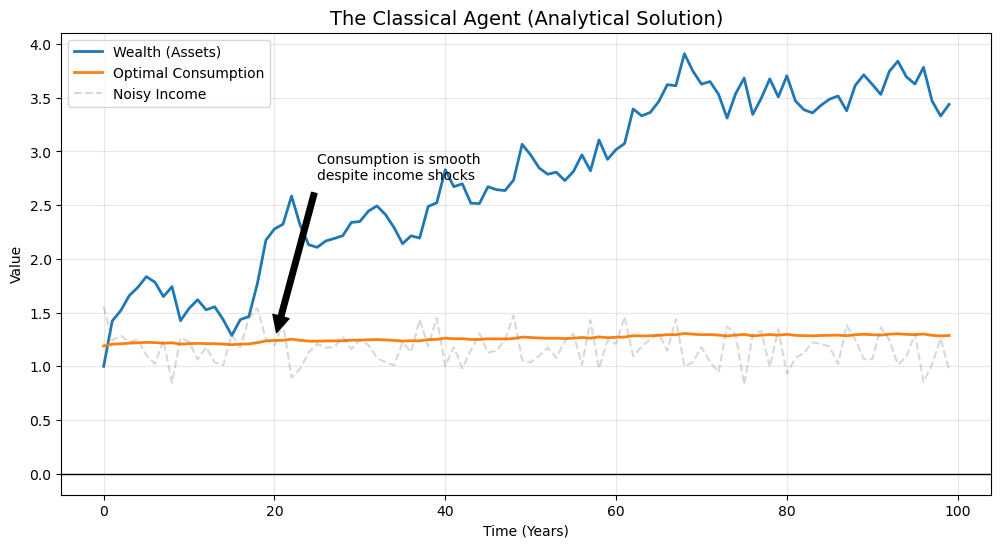

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
R = 0.04             # Interest rate
W = 1.15             # Average yearly income
SIGMA = 0.15         # Income standard deviation
THETA = 2.0          # Risk Aversion (CARA)

# --- 2. The Known Analytical Solution ---
def classical_policy(assets, r, w, sigma, theta):
    """
    Calculates consumption using the exact closed-form solution 
    for CARA utility with Gaussian income shocks.
    """
    # 1. Human Wealth (Present Value of all future income)
    # Since income W is constant on average, this is a geometric series: W/r
    human_wealth = w / r
    
    # 2. Total Permanent Income (Assets + Human Wealth) * annuity_factor
    # annuity_factor is r for infinite horizon
    pih_consumption = r * (assets + human_wealth)
    
    # 3. Precautionary Savings Correction (The "Fear Factor")
    # This is the exact constant from the derivation Caballero (1990)
    precautionary_term = (theta * r * (sigma**2)) / (2 * (1 + r)**2)
    
    return pih_consumption - precautionary_term

# --- 3. Simulation ---
T = 100
time = np.arange(T)
wealth = np.zeros(T)
consumption = np.zeros(T)
income = np.zeros(T)

wealth[0] = 1.0 # Start with some savings

# Random income shocks
np.random.seed(101)
shocks = np.random.normal(0, SIGMA, T)

for t in range(T-1):
    # A. Current Income
    current_income = W + shocks[t]
    income[t] = current_income
    
    # B. Optimal Choice (Just using the formula)
    consumption[t] = classical_policy(wealth[t], R, W, SIGMA, THETA)
    
    # C. State Evolution
    # Wealth_next = (Wealth - Cons) * (1+r) + Income_next
    # Note: Timing convention can vary, here we assume cons happens after income
    wealth[t+1] = (wealth[t] + current_income - consumption[t]) * (1 + R)

# Fill last period for plotting
income[-1] = W + shocks[-1]
consumption[-1] = classical_policy(wealth[-1], R, W, SIGMA, THETA)

# --- 4. Plotting ---
plt.figure(figsize=(12, 6))

# Plot Wealth & Consumption
plt.plot(time, wealth, label='Wealth (Assets)', linewidth=2, color='#1f77b4')
plt.plot(time, consumption, label='Optimal Consumption', linewidth=2, color='#ff7f0e')
plt.plot(time, income, label='Noisy Income', alpha=0.3, color='gray', linestyle='--')

plt.title("The Classical Agent (Analytical Solution)", fontsize=14)
plt.xlabel("Time (Years)")
plt.ylabel("Value")
plt.axhline(0, color='black', linewidth=1) # Zero line

# Add text explaining the behavior
plt.annotate('Consumption is smooth\ndespite income shocks', 
             xy=(20, consumption[20]), xytext=(25, consumption[20]+1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

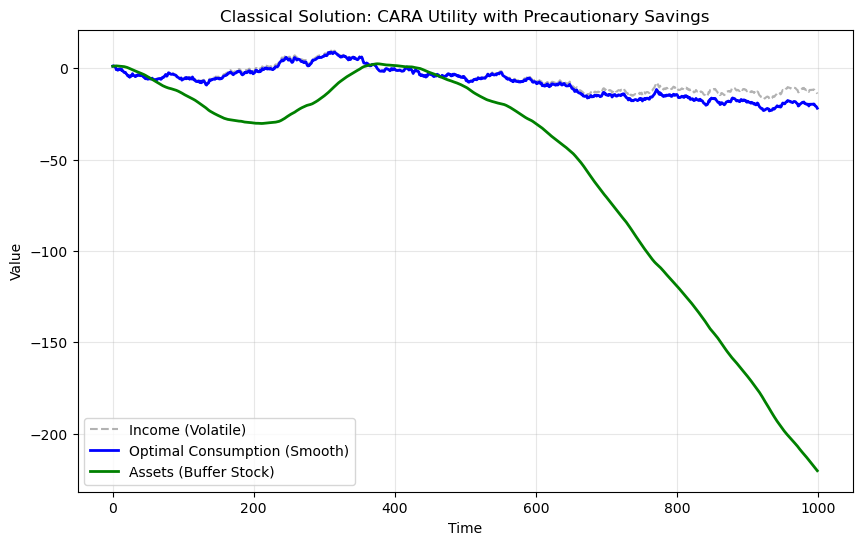

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP & PARAMETERS ---
r = 0.04              # Interest Rate
theta = 1         # Risk Aversion (CARA parameter)
sigma = 0.5       # Standard Deviation of Income Shocks
T = 1000               # Time periods

# Initial Conditions
a_0 = 1.0             # Initial Assets
y_0 = 1.15            # Initial Income

# --- 2. CALCULATE CONSTANTS ---
# The constant precautionary correction term (Gamma)
# Equation: (theta * r * sigma^2) / (2 * (1+r)^2)
gamma = (theta * r * sigma**2) / (2 * (1 + r)**2)

# --- 3. SIMULATION LOOP ---
assets = np.zeros(T)
income = np.zeros(T)
consumption = np.zeros(T)

# Set starts
assets[0] = a_0
income[0] = y_0

# Generate random shocks for the whole lifetime
np.random.seed(45)
shocks = np.random.normal(0, sigma, T)

for t in range(T):
    # Update Income (Random Walk)
    if t > 0:
        income[t] = income[t-1] + shocks[t]
    
    # --- EQ 1: HUMAN WEALTH ---
    # Present value of expected future income (y_t / r)
    human_wealth = income[t] / r
    
    # --- EQ 2: OPTIMAL CONSUMPTION ---
    # c* = r/(1+r) * (Financial + Human Wealth) - Precautionary Correction
    permanent_income = (r / (1 + r)) * (assets[t] + human_wealth)
    consumption[t] = permanent_income - gamma
    
    # --- EQ 3: ASSET EVOLUTION ---
    # a_{t+1} = (1+r) * (a_t + y_t - c_t)
    if t < T - 1:
        assets[t+1] = (1 + r) * (assets[t] + income[t] - consumption[t])

# --- 4. VISUALIZATION ---
# 
plt.figure(figsize=(10, 6))
plt.plot(income, label='Income (Volatile)', color='gray', linestyle='--', alpha=0.6)
plt.plot(consumption, label='Optimal Consumption (Smooth)', color='blue', linewidth=2)
plt.plot(assets, label='Assets (Buffer Stock)', color='green', linewidth=2)
plt.title('Classical Solution: CARA Utility with Precautionary Savings')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

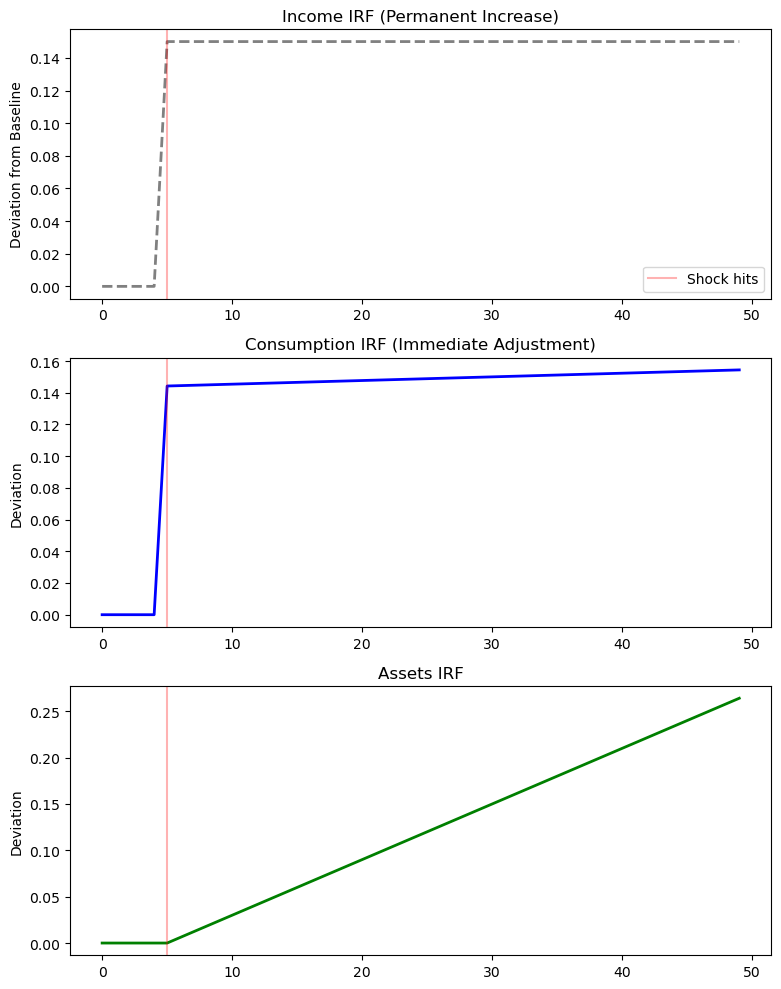

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
R = 0.04
THETA = 2.0
SIGMA = 0.15
T = 50

# Initial State
a_0 = 1.0
y_0 = 1.0

# --- 2. The Simulation Function ---
def simulate_economy(shock_sequence):
    assets = np.zeros(T)
    income = np.zeros(T)
    consumption = np.zeros(T)
    
    # Initialize
    assets[0] = a_0
    income[0] = y_0
    
    # Precautionary Constant (Gamma)
    gamma = (THETA * R * SIGMA**2) / (2 * (1 + R)**2)

    for t in range(T):
        # Update Income (Random Walk)
        if t > 0:
            income[t] = income[t-1] + shock_sequence[t]
        
        # Human Wealth (PV of future income)
        human_wealth = income[t] / R
        
        # Optimal Consumption
        # c* = r/(1+r) * (Financial + Human Wealth) - Gamma
        consumption[t] = (R / (1 + R)) * (assets[t] + human_wealth) - gamma
        
        # Asset Evolution
        if t < T - 1:
            assets[t+1] = (1 + R) * (assets[t] + income[t] - consumption[t])
            
    return income, consumption, assets

# --- 3. Create Shocks ---
# Scenario A: Baseline (No shocks ever)
shocks_baseline = np.zeros(T)

# Scenario B: Impulse (One shock at t=5)
shocks_impulse = np.zeros(T)
shocks_impulse[5] = SIGMA  # One standard deviation positive shock

# --- 4. Run Simulations ---
y_base, c_base, a_base = simulate_economy(shocks_baseline)
y_shock, c_shock, a_shock = simulate_economy(shocks_impulse)

# --- 5. Calculate IRF (Difference) ---
irf_income = y_shock - y_base
irf_consumption = c_shock - c_base
irf_assets = a_shock - a_base

# --- 6. Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

# Plot Income IRF
ax[0].plot(irf_income, color='gray', linestyle='--', linewidth=2)
ax[0].set_title("Income IRF (Permanent Increase)")
ax[0].set_ylabel("Deviation from Baseline")
ax[0].axvline(5, color='red', alpha=0.3, label='Shock hits')
ax[0].legend()

# Plot Consumption IRF
ax[1].plot(irf_consumption, color='blue', linewidth=2)
ax[1].set_title("Consumption IRF (Immediate Adjustment)")
ax[1].set_ylabel("Deviation")
ax[1].axvline(5, color='red', alpha=0.3)

# Plot Assets IRF
ax[2].plot(irf_assets, color='green', linewidth=2)
ax[2].set_title("Assets IRF")
ax[2].set_ylabel("Deviation")
ax[2].axvline(5, color='red', alpha=0.3)

plt.tight_layout()
plt.show()

Solving Base Case Model (Alpha=0.33, Beta=0.96, Kappa=0.5)...
Iteration 0: Max Error = 10.133778
Iteration 50: Max Error = 0.087206
Iteration 100: Max Error = 0.011327
Iteration 150: Max Error = 0.001471
Iteration 200: Max Error = 0.000191
Iteration 250: Max Error = 0.000025
Iteration 300: Max Error = 0.000003
Converged in 329 iterations!
Steady State Capital: ~3.400


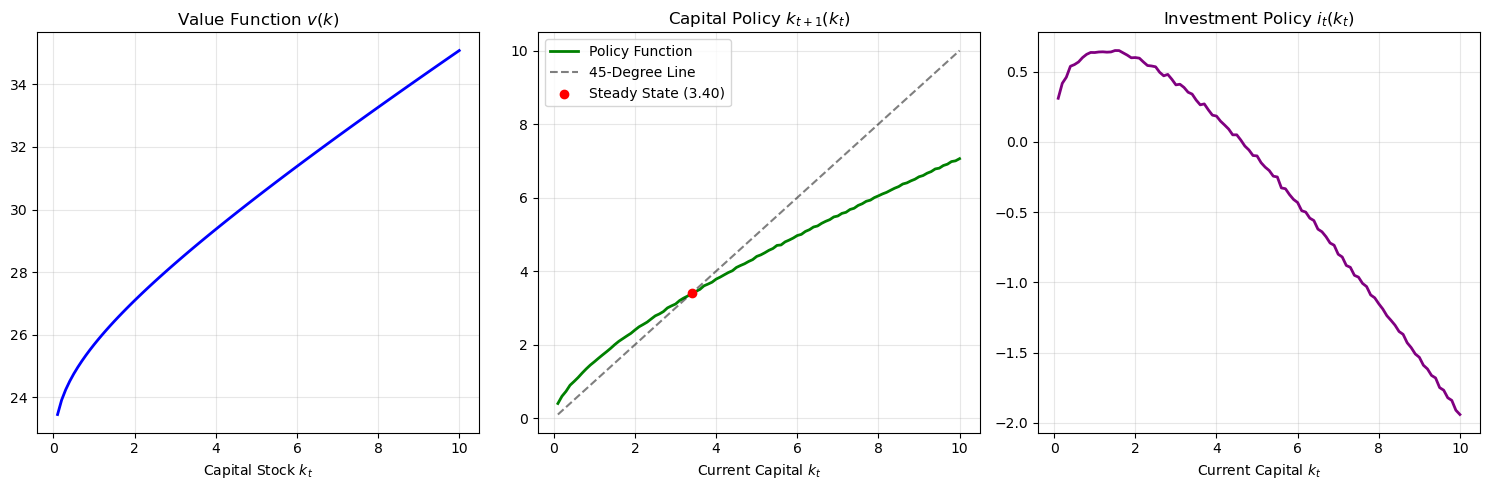

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

# ==========================================
# 1. PARAMETERS & GRID SETUP
# ==========================================
alpha = 0.33      # Capital share
beta = 0.96       # Discount factor
delta = 0.10      # Depreciation rate
kappa = 0.5       # Adjustment cost parameter (varkappa)

# Grid for Capital (State Variable)
k_min = 0.1
k_max = 10.0
n_k = 100
k_grid = np.linspace(k_min, k_max, n_k)

# ==========================================
# 2. MODEL FUNCTIONS
# ==========================================

def production(k):
    """Cobb-Douglas production function: f(k) = k^alpha"""
    return k**alpha

def get_investment_cost(k, k_next):
    """
    Calculates total investment expenditure including adjustment costs.
    Constraint: k_next = (1 - delta) * k + i
    Implies: i = k_next - (1 - delta) * k
    Cost: i * [1 + (kappa/2) * (i/k)]
    """
    i = k_next - (1 - delta) * k
    
    # Avoid division by zero
    if k < 1e-6:
        k = 1e-6
        
    adjustment_term = 1 + (kappa / 2.0) * (i / k)
    total_cost = i * adjustment_term
    return total_cost, i

def get_flow_utility(k, k_next):
    """
    Calculates dividends (d) which equals Utility in the linear case.
    d = f(k) - Investment_Cost
    """
    y = production(k)
    cost, i = get_investment_cost(k, k_next)
    d = y - cost
    return d  # u(d) = d

# ==========================================
# 3. VALUE FUNCTION ITERATION
# ==========================================

# Initial Guess: Steady state value without costs roughly f(k)/(1-beta)
v_old = production(k_grid) / (1 - beta)
v_new = np.zeros(n_k)
policy_k_next = np.zeros(n_k)

tol = 1e-6
max_iter = 1000
diff = 1.0

print(f"Solving Base Case Model (Alpha={alpha}, Beta={beta}, Kappa={kappa})...")

for it in range(max_iter):
    # Interpolate v_old to allow for off-grid optimization
    v_func_old = interp1d(k_grid, v_old, kind='linear', fill_value="extrapolate")
    
    for i, k_curr in enumerate(k_grid):
        
        # Objective function to MINIMIZE (negative of Value)
        # We maximize: u(d) + beta * v(k_next)
        def objective(k_next_val):
            flow_util = get_flow_utility(k_curr, k_next_val)
            continuation_val = v_func_old(k_next_val)
            return -(flow_util + beta * continuation_val)

        # Optimize k_next within grid bounds
        # We restrict k_next to be within [k_min, k_max] to stay on grid
        res = minimize_scalar(objective, bounds=(k_min, k_max), method='bounded')
        
        v_new[i] = -res.fun
        policy_k_next[i] = res.x

    # Check convergence
    diff = np.max(np.abs(v_new - v_old))
    v_old = v_new.copy()
    
    if it % 50 == 0:
        print(f"Iteration {it}: Max Error = {diff:.6f}")
    
    if diff < tol:
        print(f"Converged in {it} iterations!")
        break

# ==========================================
# 4. RESULTS & PLOTTING
# ==========================================

# Recover Investment Policy from Capital Policy
opt_i = np.zeros(n_k)
for idx, k in enumerate(k_grid):
    k_next = policy_k_next[idx]
    _, i_val = get_investment_cost(k, k_next)
    opt_i[idx] = i_val

# Find Approximate Steady State (where k_next intersects 45-degree line)
# We find the index where |k_next - k| is minimized
ss_idx = np.argmin(np.abs(policy_k_next - k_grid))
ss_k = k_grid[ss_idx]
print(f"Steady State Capital: ~{ss_k:.3f}")

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 1. Value Function
ax[0].plot(k_grid, v_new, linewidth=2, color='blue')
ax[0].set_title("Value Function $v(k)$")
ax[0].set_xlabel("Capital Stock $k_t$")
ax[0].grid(True, alpha=0.3)

# 2. Capital Policy Function
ax[1].plot(k_grid, policy_k_next, linewidth=2, color='green', label='Policy Function')
ax[1].plot(k_grid, k_grid, linestyle='--', color='black', alpha=0.5, label='45-Degree Line')
ax[1].scatter([ss_k], [ss_k], color='red', zorder=5, label=f'Steady State ({ss_k:.2f})')
ax[1].set_title("Capital Policy $k_{t+1}(k_t)$")
ax[1].set_xlabel("Current Capital $k_t$")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# 3. Investment Policy Function
ax[2].plot(k_grid, opt_i, linewidth=2, color='purple')
ax[2].set_title("Investment Policy $i_t(k_t)$")
ax[2].set_xlabel("Current Capital $k_t$")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

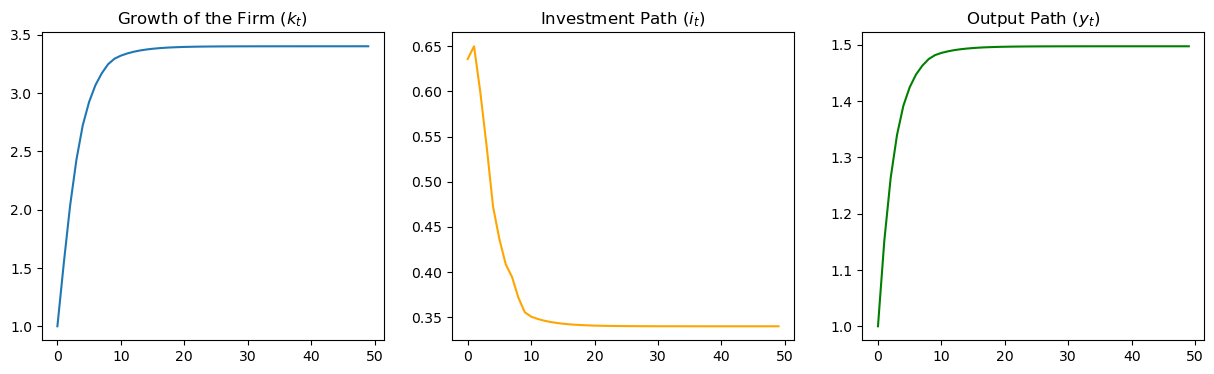

In [30]:
# --- Simulation Code (Append this to the previous script) ---

# 1. Setup Simulation
T = 50
k_path = np.zeros(T)
i_path = np.zeros(T)
y_path = np.zeros(T)

# Start small (e.g., k=1.0)
k_path[0] = 1.0 

# 2. Run the Loop
# We use the interpolated policy function for accuracy off-grid
policy_interp = interp1d(k_grid, policy_k_next, kind='linear', fill_value="extrapolate")

for t in range(T-1):
    # Production
    y_path[t] = production(k_path[t])
    
    # Decision: How much capital for tomorrow?
    k_next = policy_interp(k_path[t])
    k_path[t+1] = k_next
    
    # Investment implied by decision
    # i = k_next - (1-delta)*k
    _, i_val = get_investment_cost(k_path[t], k_next)
    i_path[t] = i_val

# Fill last period (steady state assumption)
y_path[-1] = production(k_path[-1])
i_path[-1] = delta * k_path[-1] # Just maintenance

# 3. Plot the Transition
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(k_path, label='Capital Stock')
ax[0].set_title("Growth of the Firm ($k_t$)")
ax[1].plot(i_path, color='orange', label='Investment')
ax[1].set_title("Investment Path ($i_t$)")
ax[2].plot(y_path, color='green', label='Output')
ax[2].set_title("Output Path ($y_t$)")
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

# --- 1. SETUP WITH SHOCKS ---
alpha = 0.33
beta = 0.96
delta = 0.10
kappa = 0.5
rho = 0.9       # Persistence of shock
sigma_z = 0.02  # Size of shock

# Discretize the AR(1) Shock (Tauchen's Method)
# We create a grid for z (productivity)
n_z = 5
num_std = 3.0
step = (2*num_std*sigma_z) / (n_z-1) if n_z > 1 else 0
ln_z_grid = np.linspace(-num_std*sigma_z, num_std*sigma_z, n_z) # Log Z grid
z_grid = np.exp(ln_z_grid) # Z grid
# Transition Matrix (P)
P = np.zeros((n_z, n_z))
# (Simplified Tauchen for code brevity - standard normal probabilities)
from scipy.stats import norm
for i in range(n_z):
    for j in range(n_z):
        # Probability of moving from z_i to z_j
        low = ln_z_grid[j] - step/2 - rho*ln_z_grid[i]
        high = ln_z_grid[j] + step/2 - rho*ln_z_grid[i]
        if j == 0: low = -np.inf
        if j == n_z-1: high = np.inf
        P[i, j] = norm.cdf(high/sigma_z) - norm.cdf(low/sigma_z)

# Capital Grid
k_grid = np.linspace(0.1, 10.0, 50)
n_k = len(k_grid)

# --- 2. SOLVE STOCHASTIC BELLMAN ---
# V is now V(z, k) -> Shape (n_z, n_k)
v_old = np.zeros((n_z, n_k))
policy_k = np.zeros((n_z, n_k))

for it in range(200): # Iteration loop
    v_new = np.zeros_like(v_old)
    v_func_list = [interp1d(k_grid, v_old[i,:], fill_value="extrapolate") for i in range(n_z)]
    
    for iz, z in enumerate(z_grid): # For each productivity level
        for ik, k in enumerate(k_grid):
            
            def objective(k_next):
                # Invest cost
                i_val = k_next - (1-delta)*k
                cost = i_val * (1 + (kappa/2)*(i_val/k))
                # Dividends: z * k^alpha - cost
                d = z * (k**alpha) - cost
                
                # Continuation Value: Expected value over z_next
                # E[V] = sum( Prob(z_next|z) * V(z_next, k_next) )
                expected_v = 0
                for iz_next in range(n_z):
                    expected_v += P[iz, iz_next] * v_func_list[iz_next](k_next)
                
                return -(d + beta * expected_v)
            
            # Optimization
            res = minimize_scalar(objective, bounds=(0.1, 10.0), method='bounded')
            v_new[iz, ik] = -res.fun
            policy_k[iz, ik] = res.x
            
    if np.max(np.abs(v_new - v_old)) < 1e-4:
        print(f"Converged in {it} iterations")
        break
    v_old = v_new

# --- 3. GENERATE IRF ---
# We simulate two identical firms.
# Firm A gets a shock at t=5. Firm B does not.
T_sim = 40
k_A, k_B = np.zeros(T_sim), np.zeros(T_sim)
i_A, i_B = np.zeros(T_sim), np.zeros(T_sim)
z_idx_A, z_idx_B = np.zeros(T_sim, dtype=int), np.zeros(T_sim, dtype=int)

# Initialize at Steady State (approx middle z index)
ss_z_idx = n_z // 2
current_k = 4.0 # Approx steady state
k_A[0], k_B[0] = current_k, current_k
z_idx_A[0], z_idx_B[0] = ss_z_idx, ss_z_idx

# Shock Time
shock_t = 5

for t in range(T_sim-1):
    # 1. Update Productivity
    # Firm B stays at steady state productivity (middle index)
    z_idx_B[t+1] = ss_z_idx 
    
    # Firm A gets a shock at t=5, then decays back
    if t == shock_t:
        z_idx_A[t] = n_z - 1 # Jump to highest productivity
    
    # Simple persistence for simulation: if z is high, prob of staying high is determined by P
    # For a clean IRF, we can just deterministically decay the index or state
    # Let's force the path for clarity: z decays back to mean
    if t > shock_t:
        # Decay logic (approximate)
        if z_idx_A[t] > ss_z_idx: z_idx_A[t+1] = max(ss_z_idx, z_idx_A[t] - 1)
        else: z_idx_A[t+1] = ss_z_idx
    elif t < shock_t:
        z_idx_A[t+1] = ss_z_idx

    # 2. Decisions (Policy Function)
    # Firm A
    pol_A = interp1d(k_grid, policy_k[z_idx_A[t], :], fill_value="extrapolate")
    k_A[t+1] = pol_A(k

SyntaxError: incomplete input (76470812.py, line 114)

Solving Stochastic Bellman Equation...
Iter 0: Diff = 11.985516
Iter 10: Diff = 0.747290
Iter 20: Diff = 0.394175
Iter 30: Diff = 0.235839
Iter 40: Diff = 0.148549
Iter 50: Diff = 0.096092
Iter 60: Diff = 0.063015
Iter 70: Diff = 0.041610
Iter 80: Diff = 0.027570
Iter 90: Diff = 0.018299
Iter 100: Diff = 0.012156
Iter 110: Diff = 0.008078
Iter 120: Diff = 0.005370
Iter 130: Diff = 0.003570
Iter 140: Diff = 0.002373
Iter 150: Diff = 0.001578
Iter 160: Diff = 0.001049
Iter 170: Diff = 0.000697
Iter 180: Diff = 0.000464
Iter 190: Diff = 0.000308
Steady State Capital (k_ss): 3.445


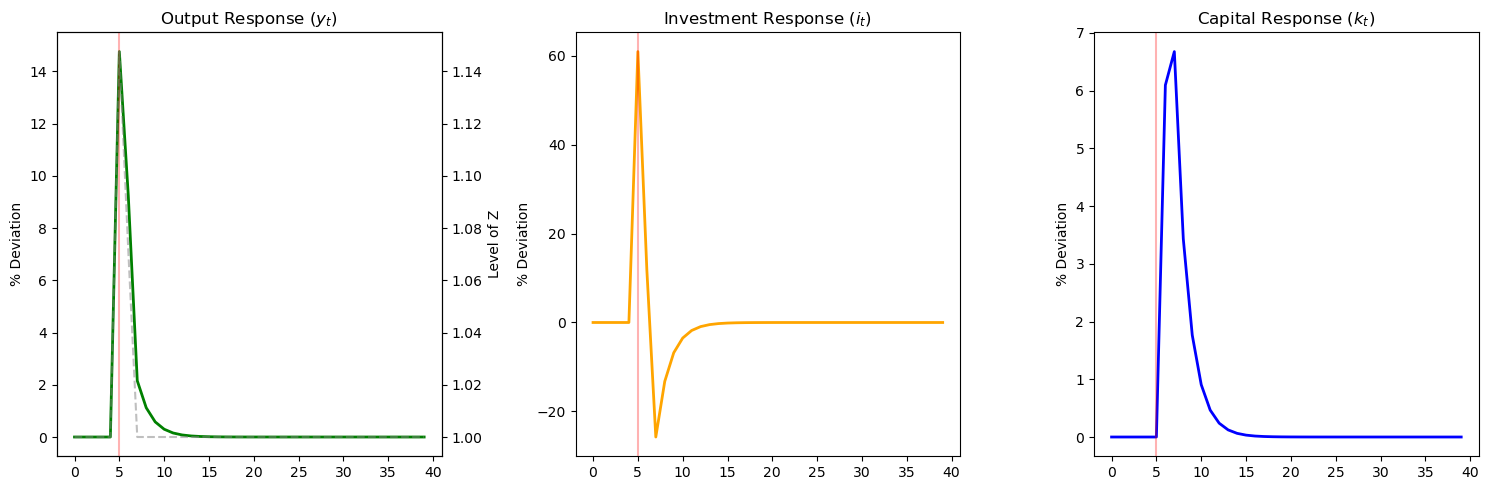

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.stats import norm

# Economic Parameters
alpha = 1.0/3.0 # Capital share
beta = 0.96 # Discount factor
delta = 0.04 # Depreciation rate

# Shock Parameters (AR(1) in logs)
rho = 0.9         # Persistence
sigma_e = 0.02    # Standard deviation of innovation epsilon
sigma_z = sigma_e / np.sqrt(1 - rho**2) # Unconditional Std Dev of log(z)

# Grid Settings
n_k = 50          # Number of capital points
k_min, k_max = 0.1, 15.0

n_z = 5           # Number of productivity shock points
num_std_z = 3.0   # Width of shock grid in std devs

# ==========================================
# 2. DISCRETIZE SHOCK (TAUCHEN'S METHOD)
# ==========================================
# We discretize ln(z) into n_z points
ln_z_grid = np.linspace(-num_std_z * sigma_z, num_std_z * sigma_z, n_z)
z_grid = np.exp(ln_z_grid)
step_z = ln_z_grid[1] - ln_z_grid[0]

# Transition Matrix P[i, j] = Prob(z_next = z_j | z_curr = z_i)
P = np.zeros((n_z, n_z))

for i in range(n_z):
    for j in range(n_z):
        # Boundaries for integration
        if j == 0:
            low = -np.inf
            high = ln_z_grid[j] + step_z / 2
        elif j == n_z - 1:
            low = ln_z_grid[j] - step_z / 2
            high = np.inf
        else:
            low = ln_z_grid[j] - step_z / 2
            high = ln_z_grid[j] + step_z / 2
        
        # Center of the conditional distribution is rho * ln(z_i)
        mean_next = rho * ln_z_grid[i]
        
        # Calculate probability mass
        P[i, j] = norm.cdf(high, loc=mean_next, scale=sigma_e) - \
                  norm.cdf(low, loc=mean_next, scale=sigma_e)

# Normalize just in case
P = P / P.sum(axis=1, keepdims=True)

# ==========================================
# 3. VALUE FUNCTION ITERATION (STOCHASTIC)
# ==========================================
k_grid = np.linspace(k_min, k_max, n_k)

# Value Function V(z_idx, k_idx)
# Guess: Steady state value without shocks ~ z * k^alpha / (1-beta)
v_old = np.zeros((n_z, n_k))
for i in range(n_z):
    v_old[i, :] = (z_grid[i] * k_grid**alpha) / (1 - beta)

policy_k = np.zeros((n_z, n_k)) # Stores optimal k' for each (z, k)

print("Solving Stochastic Bellman Equation...")

for iteration in range(200):
    v_new = np.zeros_like(v_old)
    
    # We create interpolation functions for "Expected Continuation Value"
    # Expected_V(k') depends on current z because P(z'|z) changes
    expected_v_funcs = []
    for i_z in range(n_z):
        # Calculate E[V(z', k') | z_i] for all grid points k'
        # This collapses the z dimension via expectation
        ev_grid_vals = np.dot(P[i_z, :], v_old) # Shape (n_k,)
        expected_v_funcs.append(interp1d(k_grid, ev_grid_vals, kind='linear', fill_value="extrapolate"))

    # Loop over current states
    for i_z, z in enumerate(z_grid):
        for i_k, k in enumerate(k_grid):
            
            # Objective Function (Negative R.H.S of Bellman)
            def objective(k_next):
                # Investment & Cost
                i_val = k_next - (1 - delta) * k
                adj_cost_factor = 1 + (kappa / 2) * (i_val / k)
                total_cost = i_val * adj_cost_factor
                
                # Dividends: z * f(k) - cost
                dividends = z * (k**alpha) - total_cost
                
                # Continuation Value
                continuation = expected_v_funcs[i_z](k_next)
                
                return -(dividends + beta * continuation)
            
            # Constraints on k_next (must be positive, within reason)
            res = minimize_scalar(objective, bounds=(k_min, k_max), method='bounded')
            
            v_new[i_z, i_k] = -res.fun
            policy_k[i_z, i_k] = res.x

    diff = np.max(np.abs(v_new - v_old))
    if iteration % 10 == 0:
        print(f"Iter {iteration}: Diff = {diff:.6f}")
    
    if diff < 1e-4:
        print(f"Converged in {iteration} iterations!")
        break
    
    v_old = v_new.copy()

# ==========================================
# 4. IMPULSE RESPONSE FUNCTION (IRF)
# ==========================================
# We simulate two identical firms starting at steady state.
# Firm A gets a shock to z at t=5. Firm B stays at mean z.

T_sim = 40
shock_time = 5

# Find steady state capital for mean z (index 2 in 5-point grid)
ss_z_idx = n_z // 2
ss_z_val = z_grid[ss_z_idx]

# Find k where k' = k for mean z (approximate)
# Look at policy function for middle z
pol_func_ss = interp1d(k_grid, policy_k[ss_z_idx, :], kind='linear')
k_ss = minimize_scalar(lambda k: (pol_func_ss(k) - k)**2, bounds=(k_min, k_max), method='bounded').x
print(f"Steady State Capital (k_ss): {k_ss:.3f}")

# Simulation Arrays
k_path = np.zeros(T_sim)
i_path = np.zeros(T_sim)
y_path = np.zeros(T_sim)
z_path_idx = np.zeros(T_sim, dtype=int)

# Initialize
k_path[0] = k_ss
z_path_idx[:] = ss_z_idx # Default to mean z

# Apply Shock: At t=5, z jumps to highest state (n_z - 1)
z_path_idx[shock_time] = n_z - 1
# Decay logic: After shock, deterministically decay index back to mean for clean IRF plot
# (In a real simulation, we would draw random numbers using P)
for t in range(shock_time + 1, T_sim):
    if z_path_idx[t-1] > ss_z_idx:
        z_path_idx[t] = z_path_idx[t-1] - 1 # Simple linear decay for visualization
    else:
        z_path_idx[t] = ss_z_idx

# Run Path
for t in range(T_sim - 1):
    z_curr_idx = z_path_idx[t]
    k_curr = k_path[t]
    z_curr_val = z_grid[z_curr_idx]
    
    # 1. Output
    y_path[t] = z_curr_val * (k_curr**alpha)
    
    # 2. Policy Choice k'
    pol_func = interp1d(k_grid, policy_k[z_curr_idx, :], kind='linear', fill_value="extrapolate")
    k_next = pol_func(k_curr)
    k_path[t+1] = k_next
    
    # 3. Investment
    i_path[t] = k_next - (1 - delta) * k_curr

# Fill last period
y_path[-1] = z_grid[z_path_idx[-1]] * (k_path[-1]**alpha)
i_path[-1] = delta * k_path[-1]

# Calculate deviations from Steady State (Baseline)
# Baseline is simply staying at k_ss with mean z forever
y_base = ss_z_val * (k_ss**alpha)
i_base = delta * k_ss

irf_y = (y_path - y_base) / y_base * 100 # % Deviation
irf_i = (i_path - i_base) / i_base * 100
irf_k = (k_path - k_ss) / k_ss * 100

# ==========================================
# 5. PLOTTING
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot Productivity Shock Path
ax_z = ax[0].twinx() # Add secondary axis for Z
ax[0].plot(irf_y, color='green', linewidth=2, label='Output (LHS)')
ax_z.plot(z_grid[z_path_idx], color='grey', linestyle='--', alpha=0.5, label='Productivity Z (RHS)')
ax[0].set_title("Output Response ($y_t$)")
ax[0].set_ylabel("% Deviation")
ax_z.set_ylabel("Level of Z")
ax[0].axvline(shock_time, color='red', alpha=0.3)

# Plot Investment
ax[1].plot(irf_i, color='orange', linewidth=2)
ax[1].set_title("Investment Response ($i_t$)")
ax[1].set_ylabel("% Deviation")
ax[1].axvline(shock_time, color='red', alpha=0.3)

# Plot Capital
ax[2].plot(irf_k, color='blue', linewidth=2)
ax[2].set_title("Capital Response ($k_t$)")
ax[2].set_ylabel("% Deviation")
ax[2].axvline(shock_time, color='red', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.stats import norm
from quantecon.markov.approximation import tauchen

# Economic Parameters
alpha = 1.0/3.0 # Capital share
beta = 0.96 # Discount factor
delta = 0.04 # Depreciation rate

# Shock Parameters (AR(1) in logs)
rho = 0.9         # Persistence
sigma_e = 0.02    # Standard deviation of innovation epsilon
sigma_z = sigma_e / np.sqrt(1 - rho**2) # Unconditional Std Dev of log(z)

# Grid Settings
n_k = 50          # Number of capital points
k_min, k_max = 0.1, 15.0

n_z = 5           # Number of productivity shock points
num_std_z = 3.0   # Width of shock grid in std devs

# ==========================================
# 2. DISCRETIZE SHOCK (TAUCHEN'S METHOD)
# ==========================================
# We discretize ln(z) into n_z points
ln_z_grid = np.linspace(-num_std_z * sigma_z, num_std_z * sigma_z, n_z)
z_grid = np.exp(ln_z_grid)
step_z = ln_z_grid[1] - ln_z_grid[0]

# Transition Matrix P[i, j] = Prob(z_next = z_j | z_curr = z_i)
P = np.zeros((n_z, n_z))

for i in range(n_z):
    for j in range(n_z):
        # Boundaries for integration
        if j == 0:
            low = -np.inf
            high = ln_z_grid[j] + step_z / 2
        elif j == n_z - 1:
            low = ln_z_grid[j] - step_z / 2
            high = np.inf
        else:
            low = ln_z_grid[j] - step_z / 2
            high = ln_z_grid[j] + step_z / 2
        
        # Center of the conditional distribution is rho * ln(z_i)
        mean_next = rho * ln_z_grid[i]
        
        # Calculate probability mass
        P[i, j] = norm.cdf(high, loc=mean_next, scale=sigma_e) - \
                  norm.cdf(low, loc=mean_next, scale=sigma_e)

# Normalize just in case
P = P / P.sum(axis=1, keepdims=True)

# ==========================================
# 3. VALUE FUNCTION ITERATION (STOCHASTIC)
# ==========================================
k_grid = np.linspace(k_min, k_max, n_k)

# Value Function V(z_idx, k_idx)
# Guess: Steady state value without shocks ~ z * k^alpha / (1-beta)
v_old = np.zeros((n_z, n_k))
for i in range(n_z):
    v_old[i, :] = (z_grid[i] * k_grid**alpha) / (1 - beta)

policy_k = np.zeros((n_z, n_k)) # Stores optimal k' for each (z, k)

print("Solving Stochastic Bellman Equation...")

for iteration in range(200):
    v_new = np.zeros_like(v_old)
    
    # We create interpolation functions for "Expected Continuation Value"
    # Expected_V(k') depends on current z because P(z'|z) changes
    expected_v_funcs = []
    for i_z in range(n_z):
        # Calculate E[V(z', k') | z_i] for all grid points k'
        # This collapses the z dimension via expectation
        ev_grid_vals = np.dot(P[i_z, :], v_old) # Shape (n_k,)
        expected_v_funcs.append(interp1d(k_grid, ev_grid_vals, kind='linear', fill_value="extrapolate"))

    # Loop over current states
    for i_z, z in enumerate(z_grid):
        for i_k, k in enumerate(k_grid):
            
            # Objective Function (Negative R.H.S of Bellman)
            def objective(k_next):
                # Investment & Cost
                i_val = k_next - (1 - delta) * k
                adj_cost_factor = 1 + (kappa / 2) * (i_val / k)
                total_cost = i_val * adj_cost_factor
                
                # Dividends: z * f(k) - cost
                dividends = z * (k**alpha) - total_cost
                
                # Continuation Value
                continuation = expected_v_funcs[i_z](k_next)
                
                return -(dividends + beta * continuation)
            
            # Constraints on k_next (must be positive, within reason)
            res = minimize_scalar(objective, bounds=(k_min, k_max), method='bounded')
            
            v_new[i_z, i_k] = -res.fun
            policy_k[i_z, i_k] = res.x

    diff = np.max(np.abs(v_new - v_old))
    if iteration % 10 == 0:
        print(f"Iter {iteration}: Diff = {diff:.6f}")
    
    if diff < 1e-4:
        print(f"Converged in {iteration} iterations!")
        break
    
    v_old = v_new.copy()

# ==========================================
# 4. IMPULSE RESPONSE FUNCTION (IRF)
# ==========================================
# We simulate two identical firms starting at steady state.
# Firm A gets a shock to z at t=5. Firm B stays at mean z.

T_sim = 40
shock_time = 5

# Find steady state capital for mean z (index 2 in 5-point grid)
ss_z_idx = n_z // 2
ss_z_val = z_grid[ss_z_idx]

# Find k where k' = k for mean z (approximate)
# Look at policy function for middle z
pol_func_ss = interp1d(k_grid, policy_k[ss_z_idx, :], kind='linear')
k_ss = minimize_scalar(lambda k: (pol_func_ss(k) - k)**2, bounds=(k_min, k_max), method='bounded').x
print(f"Steady State Capital (k_ss): {k_ss:.3f}")

# Simulation Arrays
k_path = np.zeros(T_sim)
i_path = np.zeros(T_sim)
y_path = np.zeros(T_sim)
z_path_idx = np.zeros(T_sim, dtype=int)

# Initialize
k_path[0] = k_ss
z_path_idx[:] = ss_z_idx # Default to mean z

# Apply Shock: At t=5, z jumps to highest state (n_z - 1)
z_path_idx[shock_time] = n_z - 1
# Decay logic: After shock, deterministically decay index back to mean for clean IRF plot
# (In a real simulation, we would draw random numbers using P)
for t in range(shock_time + 1, T_sim):
    if z_path_idx[t-1] > ss_z_idx:
        z_path_idx[t] = z_path_idx[t-1] - 1 # Simple linear decay for visualization
    else:
        z_path_idx[t] = ss_z_idx

# Run Path
for t in range(T_sim - 1):
    z_curr_idx = z_path_idx[t]
    k_curr = k_path[t]
    z_curr_val = z_grid[z_curr_idx]
    
    # 1. Output
    y_path[t] = z_curr_val * (k_curr**alpha)
    
    # 2. Policy Choice k'
    pol_func = interp1d(k_grid, policy_k[z_curr_idx, :], kind='linear', fill_value="extrapolate")
    k_next = pol_func(k_curr)
    k_path[t+1] = k_next
    
    # 3. Investment
    i_path[t] = k_next - (1 - delta) * k_curr

# Fill last period
y_path[-1] = z_grid[z_path_idx[-1]] * (k_path[-1]**alpha)
i_path[-1] = delta * k_path[-1]

# Calculate deviations from Steady State (Baseline)
# Baseline is simply staying at k_ss with mean z forever
y_base = ss_z_val * (k_ss**alpha)
i_base = delta * k_ss

irf_y = (y_path - y_base) / y_base * 100 # % Deviation
irf_i = (i_path - i_base) / i_base * 100
irf_k = (k_path - k_ss) / k_ss * 100

# ==========================================
# 5. PLOTTING
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot Productivity Shock Path
ax_z = ax[0].twinx() # Add secondary axis for Z
ax[0].plot(irf_y, color='green', linewidth=2, label='Output (LHS)')
ax_z.plot(z_grid[z_path_idx], color='grey', linestyle='--', alpha=0.5, label='Productivity Z (RHS)')
ax[0].set_title("Output Response ($y_t$)")
ax[0].set_ylabel("% Deviation")
ax_z.set_ylabel("Level of Z")
ax[0].axvline(shock_time, color='red', alpha=0.3)

# Plot Investment
ax[1].plot(irf_i, color='orange', linewidth=2)
ax[1].set_title("Investment Response ($i_t$)")
ax[1].set_ylabel("% Deviation")
ax[1].axvline(shock_time, color='red', alpha=0.3)

# Plot Capital
ax[2].plot(irf_k, color='blue', linewidth=2)
ax[2].set_title("Capital Response ($k_t$)")
ax[2].set_ylabel("% Deviation")
ax[2].axvline(shock_time, color='red', alpha=0.3)

plt.tight_layout()
plt.show()